In [34]:
import os
import json
from datetime import datetime
import plotly.graph_objects as go


# -------------------------------------------------------
# Parse timestamp from folder name
# -------------------------------------------------------
def parse_timestamp(folder_name):
    try:
        return datetime.strptime(folder_name[:19], "%Y-%m-%d %H-%M-%S")
    except:
        return None


# -------------------------------------------------------
# Load logs.json for a run folder
# -------------------------------------------------------
def load_logs(run_folder):
    json_path = os.path.join(run_folder, "logs.json")

    if not os.path.exists(json_path):
        print(f"❌ logs.json missing in: {run_folder}")
        return None

    with open(json_path, "r") as f:
        return json.load(f)


import matplotlib.pyplot as plt


def create_plot(data_dict, x_key, y_key, title):
    fig, ax = plt.subplots(figsize=(8, 5))

    for run_name, logs in data_dict.items():
        x = logs.get(x_key, [])
        y = logs.get(y_key, [])

        if len(x) == 0 or len(y) == 0:
            print(f"Missing data for {run_name} → {y_key}")
            continue

        label = run_name[20:] if len(run_name) > 20 else run_name
        ax.plot(x, y, marker='o', linestyle='-', label=label)

    ax.set_title(title)
    ax.set_xlabel(x_key)
    ax.set_ylabel(y_key)

    # ---- RIGHT-SIDE OVERLAY LEGEND ----
    ax.legend(
        loc="upper right",     # place at the top-right corner
        bbox_to_anchor=(1.0, 1.0),  # exactly top-right inside the axes
        frameon=True,
        fontsize=8
    )

    ax.grid(True, linestyle="--", alpha=0.3)

    # Let the plot touch the right edge (so legend overlaps)
    fig.subplots_adjust(right=1.0)

    return fig





def compare_runs(parent_folder, run_names, graph_types=None):
    """
    parent_folder: folder containing multiple timestamped run folders
    graph_types: list of graph types to create
    start_time, end_time: datetime filters
    """

    runs = {}

    for folder in run_names:
        run_path = os.path.join(parent_folder,folder)
        logs = load_logs(run_path)
        if logs:
            runs[folder] = logs

    if len(runs) == 0:
        print("No valid runs found in selected folder/time range")
        return {}

    print("Loaded runs:", list(runs.keys()))

    for logs in runs.values():


        cum = []
        total = 0
        for t in logs.get("batch_times", []):
            total += t
            cum.append(total)
        logs["batch_cum_time"] = cum

        # Epoch cumulative time
        cum = []
        total = 0
        for t in logs.get("epoch_times", []):
            total += t
            cum.append(total)
        logs["epoch_cum_time"] = cum

        logs["batch_index"] = list(range(len(logs.get("batch_train_losses", []))))
        logs["epoch_index"] = list(range(len(logs.get("epoch_train_losses", []))))

    ALL_GRAPHS = {
        "batch_loss": ("batch_index", "batch_train_losses"),
        "batch_acc": ("batch_index", "batch_train_accs"),

        "batch_loss_time": ("batch_cum_time", "batch_train_losses"),
        "batch_acc_time": ("batch_cum_time", "batch_train_accs"),

        "epoch_train_loss": ("epoch_index", "epoch_train_losses"),
        "epoch_train_acc": ("epoch_index", "epoch_train_accs"),

        "epoch_val_loss": ("epoch_index", "epoch_val_losses"),
        "epoch_val_acc": ("epoch_index", "epoch_val_accs"),

        "epoch_train_loss_time": ("epoch_cum_time", "epoch_train_losses"),
        "epoch_val_loss_time": ("epoch_cum_time", "epoch_val_losses"),
    }

    if graph_types is None:
        graph_types = list(ALL_GRAPHS.keys())


    output_figures = {}

    for g in graph_types:
        if g not in ALL_GRAPHS:
            print(f"Unknown graph type ignored: {g}")
            continue

        x_key, y_key = ALL_GRAPHS[g]

        fig = create_plot(
            runs,
            x_key,
            y_key,
            title=f"Comparison: {g}"
        )

        output_figures[g] = fig

    return output_figures


C:\Users\rrpra\AppData\Local\Temp\ipykernel_10940\3161216684.py:8: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.


C:\Users\rrpra\AppData\Local\Temp\ipykernel_10940\3161216684.py:47: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



Loaded runs: ['2025-11-20_07-55-52_only lstm 64 size', '2025-11-20_08-07-44_only lstm 64 size with layer normalization', '2025-11-20_08-12-38_only bilstm 64 size with layer normalization test 2', '2025-11-20_08-17-55_only bilstm 128 size with layer normalization test 2']


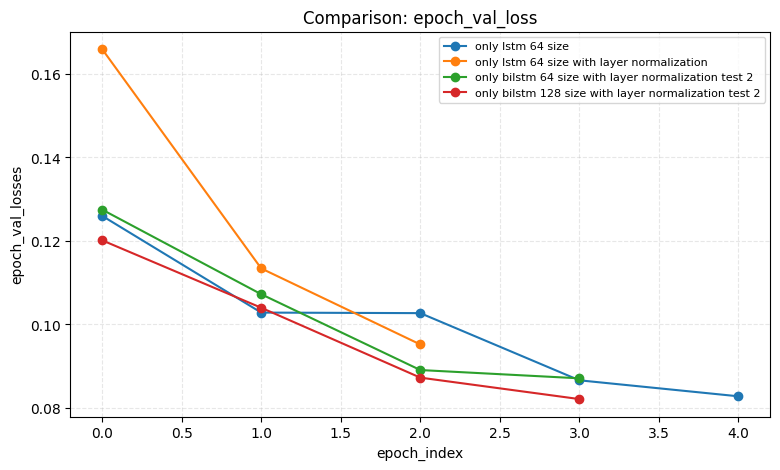

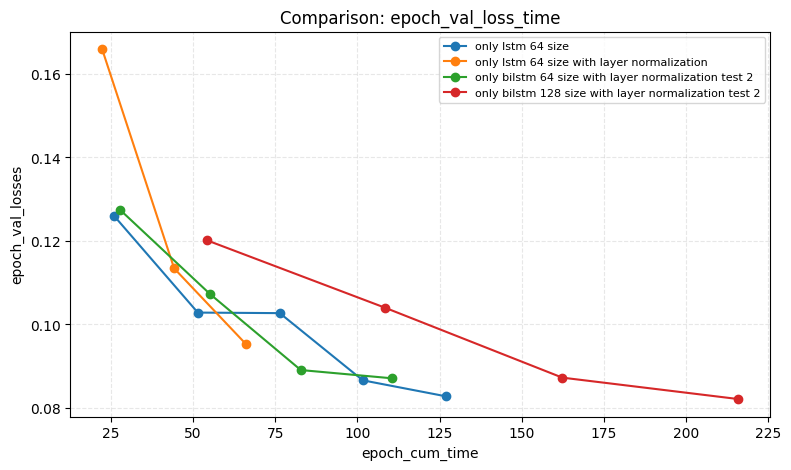

In [39]:
import plotly.io as pio
from PIL import Image
import io
import os

# fix: force Plotly to use json engine instead of kaleido executable
pio.kaleido.scope.default_engine = "json"
pio.kaleido.scope.default_format = "png"

def save_figures(figs, base_filename, save_dir="saved_graphs",name='bilstm',type=['epoch','time']):
    """
    Saves figures with filename pattern:
        base_filename + "_" + graph_type + ".png"
    """

    # create folder if not exist
    os.makedirs(save_dir, exist_ok=True)
    x=0
    for graph_type, fig in figs.items():
        filename = f"{name}_{type[x]}.png"
        filepath = os.path.join(save_dir, filename)
        x+=1
        png_bytes = pio.to_image(fig, format="png", engine="json", scale=2)

        # Convert to PIL for plain PNG
        img = Image.open(io.BytesIO(png_bytes))
        img.convert("RGB").save(filepath, "PNG")
        print(f"[saved plain PNG] {filepath}")
        print(f"[saved] {filepath}")


figs = compare_runs(
    parent_folder="training_runs",
    graph_types=["epoch_val_loss", "epoch_val_loss_time"],
    run_names=[
        '2025-11-20_07-55-52_only lstm 64 size',
        '2025-11-20_08-07-44_only lstm 64 size with layer normalization',
        '2025-11-20_08-12-38_only bilstm 64 size with layer normalization test 2',
        '2025-11-20_08-17-55_only bilstm 128 size with layer normalization test 2'
    ]
)



# optional: show graphs
for fig_name in figs:
    figs[fig_name].show()



In [29]:
import os
import json

BASE_DIR = "./training_runs"   # root directory containing all experiment folders

results = []

def read_json(path):
    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

for folder in sorted(os.listdir(BASE_DIR)):
    full_path = os.path.join(BASE_DIR, folder)
    if not os.path.isdir(full_path):
        continue

    test_metrics_path = os.path.join(full_path, "test_metrics.json")
    logs_path = os.path.join(full_path, "logs.json")

    test_acc = None
    val_acc = None

    # --- Read test_metrics.json if exists ---
    if os.path.exists(test_metrics_path):
        tm = read_json(test_metrics_path)
        if tm and "accuracy" in tm:
            test_acc = tm["accuracy"]

    # --- Otherwise use logs.json ---
    if  os.path.exists(logs_path):
        logs = read_json(logs_path)
        if logs and "epoch_val_accs" in logs:
            val_acc = logs["epoch_val_accs"][-1]
            total_time = sum(logs["epoch_times"])

    # Determine final accuracy to store
    final_acc = test_acc if test_acc is not None else val_acc

    results.append({
        "folder": folder,
        "test_accuracy": test_acc,
        "val_accuracy_used": val_acc,
        "final_accuracy": final_acc,
        "total_time": total_time
    })

# Print Table
print("\n=== ACCURACY SUMMARY ===\n")
for r in results:
    print(f"{r['folder']}:  final_acc={r['final_accuracy']},"
          f"  test_acc={r['test_accuracy']}, val_acc={r['val_accuracy_used']}, total_time={r['total_time']}")



=== ACCURACY SUMMARY ===

2025-11-20_07-40-37_only bilstm 64 size:  final_acc=0.9680796529968454,  test_acc=0.9680796529968454, val_acc=0.9688873991995111, total_time=96.08649940002942
2025-11-20_07-44-10_only bilstm 128 size:  final_acc=0.9689471608832808,  test_acc=0.9689471608832808, val_acc=0.9699520889607445, total_time=177.63643200002844
2025-11-20_07-49-32_only bilstm 32 size:  final_acc=0.9665615141955836,  test_acc=0.9665615141955836, val_acc=0.9672114986494214, total_time=126.00734570005443
2025-11-20_07-55-52_only lstm 64 size:  final_acc=0.9702878548895899,  test_acc=0.9702878548895899, val_acc=0.971667422464954, total_time=126.93367220007349
2025-11-20_07-58-58_only lstm 128 size:  final_acc=0.9520307570977918,  test_acc=0.9520307570977918, val_acc=0.9527396044874702, total_time=107.68109579995507
2025-11-20_08-03-13_only lstm 128 size with layer normalization:  final_acc=0.9684542586750788,  test_acc=0.9684542586750788, val_acc=0.9691634298783494, total_time=104.43038260

In [1]:
import os
import json
import plotly.graph_objects as go
import numpy as np

def plot_training_graphs(folder_path):
    """Reads logs.json from folder_path and plots:
       1. Cumulative Time vs Validation Accuracy
       2. Epoch vs Training Loss vs Validation Loss
    """

    log_file = os.path.join(folder_path, "logs.json")

    # ---- Load JSON ----
    with open(log_file, "r") as f:
        data = json.load(f)

    epoch_val_accs = data["epoch_val_accs"]
    epoch_val_losses = data["epoch_val_losses"]
    epoch_train_losses = data["epoch_train_losses"]
    epoch_times = data["epoch_times"]

    epochs = list(range(1, len(epoch_val_accs) + 1))

    # --------- Make cumulative time ---------
    cumulative_time = np.cumsum(epoch_times)

    # ======================= GRAPH 1 ==========================
    # Cumulative Time vs Validation Accuracy
    fig1 = go.Figure()
    fig1.add_trace(go.Scatter(
        x=cumulative_time,
        y=epoch_val_accs,
        mode='lines+markers',
        name='Validation Accuracy'
    ))

    fig1.update_layout(
        title="Cumulative Time vs Validation Accuracy",
        xaxis_title="Cumulative Time (seconds)",
        yaxis_title="Validation Accuracy",
        template="plotly_white"
    )

    fig1.show()

    # ======================= GRAPH 2 ==========================
    # Epoch vs Training Loss vs Validation Loss
    fig2 = go.Figure()

    fig2.add_trace(go.Scatter(
        x=epochs,
        y=epoch_train_losses,
        mode='lines+markers',
        name="Training Loss"
    ))

    fig2.add_trace(go.Scatter(
        x=epochs,
        y=epoch_val_losses,
        mode='lines+markers',
        name="Validation Loss"
    ))

    fig2.update_layout(
        title="Epoch vs Training Loss vs Validation Loss",
        xaxis_title="Epoch",
        yaxis_title="Loss",
        template="plotly_white"
    )

    fig2.show()


In [8]:
plot_training_graphs(r"training_runs\2025-11-23_11-36-46_final_model_on_dataset_Dataset 1 (Malicious URLs)")


In [28]:
import os
import json
import pandas as pd

def read_all_metrics(base_folder):
    results = []

    # iterate through items in base folder
    for folder in os.listdir(base_folder):
        folder_path = os.path.join(base_folder, folder)

        # only process directories
        if not os.path.isdir(folder_path):
            continue

        json_path = os.path.join(folder_path, "test_metrics.json")

        # skip if file doesn't exist
        if not os.path.exists(json_path):
            print(f"⚠️ Skipping {folder} → test_metrics.json not found")
            continue

        # load json
        try:
            with open(json_path, "r") as f:
                data = json.load(f)

            # extract only top-level metrics
            results.append({
                "folder": folder,
                "accuracy": data.get("accuracy"),
                "precision": data.get("precision"),
                "recall": data.get("recall"),
                "f1": data.get("f1"),
                "roc_auc": data.get("roc_auc"),
                "r2_score": data.get("r2_score"),
            })

        except Exception as e:
            print(f"❌ Error reading {json_path}: {e}")

    # convert to DataFrame
    df = pd.DataFrame(results)
    return df


# -----------------------------
# 🔹 USE IT LIKE THIS
# -----------------------------
base_folder = r"training_runs"

df = read_all_metrics(base_folder)
print(df)

# OPTIONAL: save to CSV
df.to_csv("all_model_metrics.csv", index=False)
print("\n✔ Saved all_model_metrics.csv")


⚠️ Skipping 2025-11-23_11-53-06_final_model_on_dataset_Dataset 2 (ndarvind → test_metrics.json not found
⚠️ Skipping 2025-11-23_12-00-36_final_model_on_dataset_Dataset 3 (kmack → test_metrics.json not found
⚠️ Skipping 2025-11-23_12-22-20_final_model_on_dataset_Dataset 4 (kaggels → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-35-17_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-36-34_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-37-24_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-40-40_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-41-51_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-45-32_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-47-53_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_16-52-37_my_experiment → test_metrics.json not found
⚠️ Skipping 2025-11-23_17-02-20_my_experiment → test_metrics.json not found
⚠️ Sk